<a href="https://colab.research.google.com/github/oliviahong-lgtm/RSNA_Pneumonia_Final_Experiment/blob/main/RSNA_Pneumonia_Final_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"huijeonghong","key":"08fa56f7c9518d4bb29aec272b190d9a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge

100% 3.66G/3.66G [01:42<00:00, 38.5MB/s]



In [ ]:
!kaggle datasets download -d <데이터셋 이름>

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `kaggle datasets download -d <데이터셋 이름>'


In [ ]:
!unzip rsna-pneumonia-detection-challenge.zip

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: stage_2_train_images/d5231546-354e-4071-9af1-6644beabfd86.dcm  
  inflating: stage_2_train_images/d5252a78-3ea1-48e9-9ffb-e7535be3ce80.dcm  
  inflating: stage_2_train_images/d525eafb-8908-45fd-a942-48d07c435487.dcm  
  inflating: stage_2_train_images/d5265640-17db-4880-866d-d2952e32941c.dcm  
  inflating: stage_2_train_images/d5277276-f8f8-40e9-b8e1-791cf5d96ac0.dcm  
  inflating: stage_2_train_images/d528d9e9-647a-4e2e-a16c-bd5e32a5bbf5.dcm  
  inflating: stage_2_train_images/d5293a3e-f050-4b98-8bbf-1f40e25bced5.dcm  
  inflating: stage_2_train_images/d52cbb5a-1d0a-457d-8c72-0f7aeec21ca7.dcm  
  inflating: stage_2_train_images/d52ce67b-be7c-4349-8dc4-38562928d208.dcm  
  inflating: stage_2_train_images/d535a3c8-c4a4-4856-b5cd-17f6332eac8b.dcm  
  inflating: stage_2_train_images/d5360dc4-6bea-4a7b-bc49-5b2547ad7877.dcm  
  inflating: stage_2_train_images/d5364bc1-bc2a-4bd0-a1bd-0cfb5a369ccc.dcm  
  inflating: stage_2_train_images/d539e1

In [ ]:
# =========================================================
# Google Drive connection test for Colab
# Run this cell BEFORE the long experiment.
# =========================================================

import os
from google.colab import drive

DRIVE_ROOT = "/content/drive"
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/RSNA_Pneumonia_Final_Experiment"

try:
    drive.mount(DRIVE_ROOT, force_remount=False)
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

    test_file = os.path.join(DRIVE_OUTPUT_DIR, "drive_connection_test.txt")
    with open(test_file, "w") as f:
        f.write("Google Drive connection test successful.\n")

    print("✅ Google Drive connected successfully.")
    print("✅ Test file saved to:", test_file)

except Exception as e:
    print("❌ Google Drive connection failed.")
    print("Error:", e)
    print("Do NOT start the long experiment until this is fixed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected successfully.
✅ Test file saved to: /content/drive/MyDrive/RSNA_Pneumonia_Final_Experiment/drive_connection_test.txt


In [ ]:
!pip install pydicom
import os
import pydicom
import numpy as np
import cv2
from tqdm import tqdm
import glob

def convert_dicom_to_png(input_dir, output_dir):
    """
    지정된 폴더 내의 모든 DICOM 파일을 찾아 PNG로 변환하고 저장합니다.
    """
    # 저장할 폴더가 없으면 생성
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"📁 출력 폴더를 생성했습니다: {output_dir}")

    # input_dir 내부의 모든 .dcm 파일 경로 찾기
    dcm_files = glob.glob(os.path.join(input_dir, '**', '*.dcm'), recursive=True)

    if len(dcm_files) == 0:
        print("❌ 지정한 경로에서 DICOM 파일을 찾을 수 없습니다.")
        return

    print(f"🚀 총 {len(dcm_files)}개의 DICOM 파일 변환을 시작합니다...")

    # tqdm을 사용해 진행률 상태바 표시
    for dcm_path in tqdm(dcm_files, desc="Converting"):
        try:
            # 1. DICOM 파일 읽기
            dcm = pydicom.dcmread(dcm_path)

            # 2. 픽셀 데이터(배열) 추출
            img_array = dcm.pixel_array.astype(float)

            # 3. 픽셀 값 정규화 (Min-Max Scaling -> 0~255)
            # 의료 영상은 픽셀 범위가 넓으므로 일반 이미지(8-bit) 포맷으로 맞춥니다.
            img_min = np.min(img_array)
            img_max = np.max(img_array)

            if img_max > img_min:  # 0으로 나누는 오류 방지
                img_normalized = (img_array - img_min) / (img_max - img_min) * 255.0
            else:
                img_normalized = img_array

            img_normalized = np.uint8(img_normalized)

            # 4. MONOCHROME1 처리 (배경이 하얗고 뼈가 검은 경우 색상 반전)
            # RSNA 데이터는 보통 MONOCHROME2 지만, 예외를 대비한 안전 장치입니다.
            if hasattr(dcm, 'PhotometricInterpretation') and dcm.PhotometricInterpretation == "MONOCHROME1":
                img_normalized = cv2.bitwise_not(img_normalized)

            # 5. 파일명 추출 및 PNG로 저장
            # 원본 파일명에서 확장자만 .png로 변경
            file_name = os.path.basename(dcm_path).replace('.dcm', '.png')
            save_path = os.path.join(output_dir, file_name)

            cv2.imwrite(save_path, img_normalized)

        except Exception as e:
            print(f"\n⚠️ 에러 발생 파일: {dcm_path} | 사유: {e}")

    print("✅ 모든 변환 작업이 완료되었습니다!")

# ==========================================
# 실행 부분
# ==========================================
if __name__ == "__main__":
    # TODO: 본인의 PC나 서버 환경에 맞게 경로를 수정하세요.
    # 예시: 캐글에서 다운받은 stage_2_train_images 폴더 경로
    #INPUT_DICOM_DIR = r'/kaggle/input/rsna-pneumonia-detection-challenge/stage_2_train_images'
    INPUT_DICOM_DIR = '/content/stage_2_train_images'
    # 예시: 새로 저장할 PNG 폴더 경로
    #OUTPUT_PNG_DIR = './stage_2_train_png_images'
    OUTPUT_PNG_DIR = '/content/stage_2_train_png_images'
    convert_dicom_to_png(INPUT_DICOM_DIR, OUTPUT_PNG_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.7 MB/s eta 0:00:00
📁 출력 폴더를 생성했습니다: /content/stage_2_train_png_images
🚀 총 26684개의 DICOM 파일 변환을 시작합니다...


Converting: 100%|██████████| 26684/26684 [13:34<00:00, 32.77it/s]

✅ 모든 변환 작업이 완료되었습니다!


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Apr 30 16:12:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

✅ Device: cuda
CSV file exists: True
PNG folder exists: True
Number of PNG files: 26684
Total usable PNG images: 26684
Target
0    20672
1     6012
Name: count, dtype: int64
📊 Split complete - Train: 21347, Val: 2668, Test: 2669
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 233MB/s]



🔥 Training baseline: ResNet-50
Learning rate: 0.0001


ResNet-50 Train 1/10:   0%|          | 0/668 [00:00<?, ?it/s]

ResNet-50 Val 1/10:   0%|          | 0/84 [00:00<?, ?it/s]

...

Proposed Hybrid (ResNet KD) Final Test:   0%|          | 0/84 [00:00<?, ?it/s]


 Proposed Hybrid (ResNet KD)
Validation: {'Model': 'Proposed Hybrid (ResNet KD)', 'Params (M)': 0.2198, 'Accuracy (%)': 80.7346, 'Precision': 0.6096, 'Recall': 0.4027, 'F1-Score': 0.485, 'AUC': np.float64(0.8205)}
Test      : {'Model': 'Proposed Hybrid (ResNet KD)', 'Params (M)': 0.2198, 'Accuracy (%)': 80.3297, 'Precision': 0.5964, 'Recall': 0.391, 'F1-Score': 0.4724, 'AUC': np.float64(0.8052)}


Proposed Hybrid (ViT KD) Final Val:   0%|          | 0/84 [00:00<?, ?it/s]

Proposed Hybrid (ViT KD) Final Test:   0%|          | 0/84 [00:00<?, ?it/s]


 Proposed Hybrid (ViT KD)
Validation: {'Model': 'Proposed Hybrid (ViT KD)', 'Params (M)': 0.1366, 'Accuracy (%)': 80.0225, 'Precision': 0.6288, 'Recall': 0.2762, 'F1-Score': 0.3838, 'AUC': np.float64(0.8132)}
Test      : {'Model': 'Proposed Hybrid (ViT KD)', 'Params (M)': 0.1366, 'Accuracy (%)': 79.4305, 'Precision': 0.5929, 'Recall': 0.2762, 'F1-Score': 0.3768, 'AUC': np.float64(0.7928)}

✅ Saved:
/content/epoch_history.csv
/content/final_validation_results.csv
/content/final_test_results.csv

✅ Saved Proposed ViT KD predictions:
/content/test_predictions_proposed_vitkd.csv
/content/y_true_test_proposed_vitkd.npy
/content/y_pred_test_proposed_vitkd.npy
/content/y_prob_test_proposed_vitkd.npy


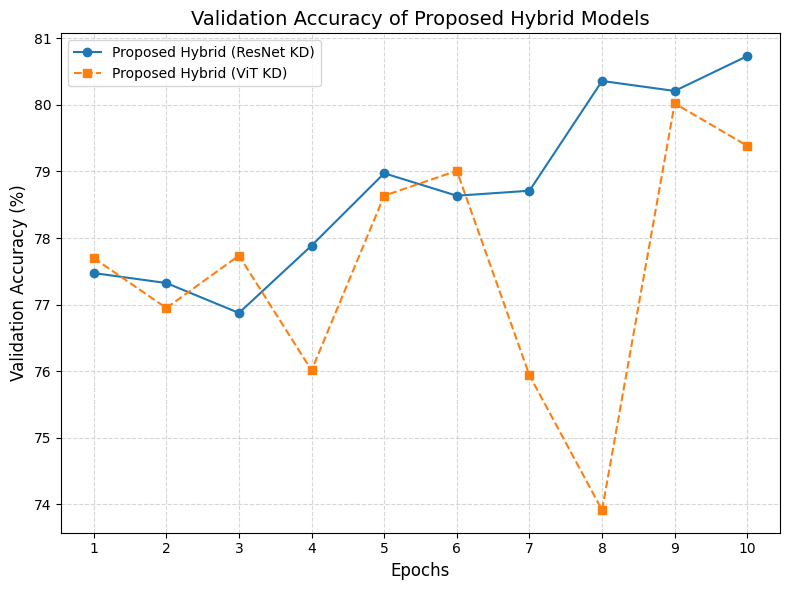


✅ Saved Figure 2: /content/figure2_validation_accuracy.png

Figure 3 consistency check
Raw confusion matrix:
[[1954  114]
 [ 435  166]]

Row-normalized confusion matrix:
[[0.94487427 0.05512573]
 [0.72379368 0.27620632]]

Pneumonia recall from confusion matrix: 0.2762
AUC from ROC curve: 0.7928


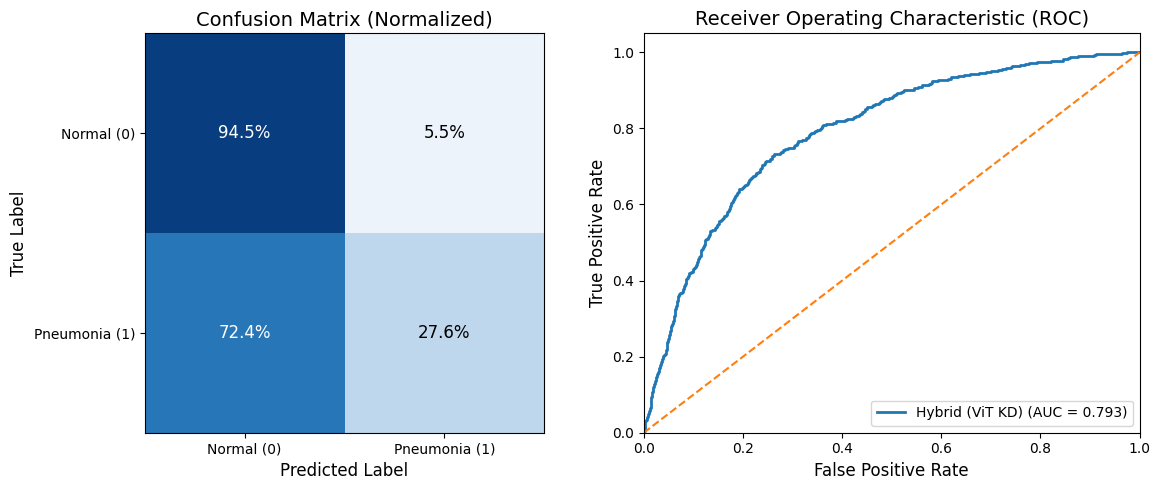


✅ Saved Figure 3: /content/figure3_vitkd_testset.png

FINAL CONSISTENCY SUMMARY: Proposed Hybrid (ViT KD), held-out test set
Accuracy (%) : 79.43
Precision    : 0.593
Recall       : 0.276
F1-Score     : 0.377
AUC          : 0.793
Params (M)   : 0.1366
CM Recall    : 0.276
✅ All computations completed.


In [ ]:
# =========================================================
# FINAL UNIFIED KAGGLE SCRIPT
# RSNA Pneumonia Detection
# PNG-based pipeline
# Train / Val / Test = 0.8 / 0.1 / 0.1
# 10 epochs for all reported models
# Saves:
# - final_test_results.csv
# - epoch_history.csv
# - test_predictions_proposed_vitkd.csv
# - figure2_validation_accuracy.png
# - figure3_vitkd_testset.png
# =========================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

try:
    import timm
except ImportError:
    os.system("pip install timm -q")
    import timm


# =========================================================
# 0. Reproducibility
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)


# =========================================================
# 1. Paths for Google Colab
# =========================================================
CSV_PATH = "/content/stage_2_train_labels.csv"
PNG_DIR = "/content/stage_2_train_png_images"

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

if not os.path.exists(PNG_DIR):
    raise FileNotFoundError(
        f"PNG directory not found: {PNG_DIR}\n"
        "먼저 DICOM -> PNG 변환이 완료되었는지, 또는 PNG 폴더 경로가 맞는지 확인하세요."
    )

print("CSV file exists:", os.path.exists(CSV_PATH))
print("PNG folder exists:", os.path.exists(PNG_DIR))
print("Number of PNG files:", len(os.listdir(PNG_DIR)))


# =========================================================
# 2. Dataset
# =========================================================
class RSNAPneumoniaPNGDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = self.df.loc[idx, "patientId"]
        img_path = os.path.join(self.img_dir, f"{patient_id}.png")

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"PNG file not found: {img_path}")

        image = Image.open(img_path).convert("RGB")
        label = int(self.df.loc[idx, "Target"])

        if self.transform:
            image = self.transform(image)

        return image, label


# =========================================================
# 3. Load labels and split
# =========================================================
full_df = pd.read_csv(CSV_PATH)

# 중복 patientId 제거
full_df = full_df.drop_duplicates(subset="patientId").reset_index(drop=True)

# 실제 PNG가 존재하는 파일만 사용
full_df["png_path"] = full_df["patientId"].apply(lambda x: os.path.join(PNG_DIR, f"{x}.png"))
full_df = full_df[full_df["png_path"].apply(os.path.exists)].reset_index(drop=True)

print("Total usable PNG images:", len(full_df))
print(full_df["Target"].value_counts())

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.2,
    random_state=42,
    stratify=full_df["Target"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["Target"]
)

print(f"📊 Split complete - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


# =========================================================
# 4. Transforms and DataLoaders
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = RSNAPneumoniaPNGDataset(train_df, PNG_DIR, transform=train_transform)
val_dataset   = RSNAPneumoniaPNGDataset(val_df,   PNG_DIR, transform=eval_transform)
test_dataset  = RSNAPneumoniaPNGDataset(test_df,  PNG_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False)


# =========================================================
# 5. Teacher Models
# =========================================================
class TeacherCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.classifier = nn.Linear(resnet.fc.in_features, num_classes)

    def forward(self, x):
        feat = self.features(x)
        feat = torch.flatten(feat, 1)
        logits = self.classifier(feat)
        return logits, feat


class TeacherViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        n = x.shape[0]
        x = self.backbone._process_input(x)
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        feat = x[:, 0]
        logits = self.backbone.heads(feat)
        return logits, feat


# =========================================================
# 6. Student Model
# =========================================================
class HybridStudent(nn.Module):
    def __init__(self, num_classes=2, teacher_feat_dim=2048):
        super().__init__()

        self.cnn_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True,
            dropout=0.1
        )

        self.transformer_encoder = nn.TransformerEncoder(
            self.transformer_layer,
            num_layers=1
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.feature_align = nn.Linear(64, teacher_feat_dim)
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.cnn_extractor(x)
        b, c, h, w = x.shape

        x_flat = x.view(b, c, -1).permute(0, 2, 1)
        trans_out = self.transformer_encoder(x_flat)
        trans_out = trans_out.permute(0, 2, 1).view(b, c, h, w)

        pooled = self.global_pool(trans_out)
        student_feat = torch.flatten(pooled, 1)

        logits = self.classifier(student_feat)
        aligned_feat = self.feature_align(student_feat)

        return logits, aligned_feat


# =========================================================
# 7. Loss and utility functions
# =========================================================
def feature_distillation_loss(student_logits, student_feat, teacher_feat, labels, alpha=0.7):
    ce_loss = F.cross_entropy(student_logits, labels)
    kd_loss = F.mse_loss(student_feat, teacher_feat)
    total_loss = alpha * ce_loss + (1 - alpha) * kd_loss
    return total_loss, ce_loss, kd_loss


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6


def save_best_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_best_state(model, state_dict):
    model.load_state_dict(state_dict)


def get_logits(outputs):
    if isinstance(outputs, tuple):
        return outputs[0]
    return outputs


def evaluate_with_predictions(model, loader, model_type="baseline", desc="Evaluation"):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    running_correct = 0
    running_total = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for inputs, labels in pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            logits = get_logits(outputs)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            current_acc = 100.0 * running_correct / max(running_total, 1)
            pbar.set_postfix({"acc": f"{current_acc:.2f}%"})

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    metrics = {
        "Accuracy (%)": accuracy_score(y_true, y_pred) * 100.0,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob),
    }

    return metrics, y_true, y_pred, y_prob


# =========================================================
# 8. Build models
# =========================================================
def build_baseline_model(model_name):
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, 2)
        lr = 1e-4
        display_name = "ResNet-50"

    elif model_name == "vit_b_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        model.heads.head = nn.Linear(model.heads.head.in_features, 2)
        lr = 1e-4
        display_name = "ViT-Base"

    elif model_name == "deit_tiny":
        model = timm.create_model("deit_tiny_patch16_224", pretrained=True, num_classes=2)
        lr = 5e-5
        display_name = "DeiT-Tiny"

    elif model_name == "mobilenetv3_small":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)
        lr = 5e-4
        display_name = "MobileNetV3-Small"

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
        lr = 1e-4
        display_name = "EfficientNet-B0"

    elif model_name == "mobilevit_xxs":
        model = timm.create_model("mobilevit_xxs.cvnets_in1k", pretrained=True, num_classes=2)
        lr = 1e-4
        display_name = "MobileViT-XXS"

    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    return model.to(device), lr, display_name


def build_teacher_model(teacher_type):
    if teacher_type == "resnet50":
        teacher = TeacherCNN().to(device)
        teacher_feat_dim = 2048
        display_name = "Proposed Hybrid (ResNet KD)"
    elif teacher_type == "vit_b_16":
        teacher = TeacherViT().to(device)
        teacher_feat_dim = 768
        display_name = "Proposed Hybrid (ViT KD)"
    else:
        raise ValueError(f"Unsupported teacher type: {teacher_type}")

    return teacher, teacher_feat_dim, display_name


# =========================================================
# 9. Training functions
# =========================================================
history_rows = []


def train_baseline(model_name, num_epochs=10):
    model, lr, display_name = build_baseline_model(model_name)

    print(f"\n🔥 Training baseline: {display_name}")
    print(f"Learning rate: {lr}")

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        model.train()

        epoch_losses = []
        running_correct = 0
        running_total = 0

        train_pbar = tqdm(train_loader, desc=f"{display_name} Train {epoch}/{num_epochs}")

        for inputs, labels in train_pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            logits = model(inputs)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

            preds = torch.argmax(logits, dim=1)
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

        train_loss = float(np.mean(epoch_losses))
        train_acc = 100.0 * running_correct / max(running_total, 1)

        val_metrics, _, _, _ = evaluate_with_predictions(
            model, val_loader, desc=f"{display_name} Val {epoch}/{num_epochs}"
        )

        history_rows.append({
            "Model": display_name,
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train Accuracy (%)": train_acc,
            "Val Accuracy (%)": val_metrics["Accuracy (%)"],
            "Val Precision": val_metrics["Precision"],
            "Val Recall": val_metrics["Recall"],
            "Val F1-Score": val_metrics["F1-Score"],
            "Val AUC": val_metrics["AUC"],
            "Learning Rate": lr,
        })

        print(
            f"✨ {display_name} | Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {val_metrics['Accuracy (%)']:.2f}% | "
            f"F1: {val_metrics['F1-Score']:.3f} | "
            f"AUC: {val_metrics['AUC']:.3f}"
        )

        if val_metrics["Accuracy (%)"] > best_val_acc:
            best_val_acc = val_metrics["Accuracy (%)"]
            best_state = save_best_state(model)

    load_best_state(model, best_state)
    return model, display_name


def train_kd_student(teacher_type, num_epochs=10, alpha=0.7):
    teacher, teacher_feat_dim, display_name = build_teacher_model(teacher_type)
    student = HybridStudent(teacher_feat_dim=teacher_feat_dim).to(device)

    print(f"\n🔥 Training KD student: {display_name}")
    print(f"Teacher feature dim: {teacher_feat_dim}")
    print("Learning rate: 0.001")
    print(f"Alpha: {alpha}")

    teacher.eval()
    optimizer = optim.AdamW(student.parameters(), lr=0.001)

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        student.train()

        total_losses = []
        ce_losses = []
        kd_losses = []

        running_correct = 0
        running_total = 0

        train_pbar = tqdm(train_loader, desc=f"{display_name} Train {epoch}/{num_epochs}")

        for inputs, labels in train_pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.no_grad():
                _, teacher_feat = teacher(inputs)

            student_logits, student_feat = student(inputs)

            loss, ce_loss, kd_loss = feature_distillation_loss(
                student_logits,
                student_feat,
                teacher_feat,
                labels,
                alpha=alpha
            )

            loss.backward()
            optimizer.step()

            total_losses.append(loss.item())
            ce_losses.append(ce_loss.item())
            kd_losses.append(kd_loss.item())

            preds = torch.argmax(student_logits, dim=1)
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "ce": f"{ce_loss.item():.4f}",
                "kd": f"{kd_loss.item():.4f}",
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

        train_loss = float(np.mean(total_losses))
        train_ce_loss = float(np.mean(ce_losses))
        train_kd_loss = float(np.mean(kd_losses))
        train_acc = 100.0 * running_correct / max(running_total, 1)

        val_metrics, _, _, _ = evaluate_with_predictions(
            student, val_loader, model_type="student", desc=f"{display_name} Val {epoch}/{num_epochs}"
        )

        history_rows.append({
            "Model": display_name,
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train CE Loss": train_ce_loss,
            "Train KD Loss": train_kd_loss,
            "Train Accuracy (%)": train_acc,
            "Val Accuracy (%)": val_metrics["Accuracy (%)"],
            "Val Precision": val_metrics["Precision"],
            "Val Recall": val_metrics["Recall"],
            "Val F1-Score": val_metrics["F1-Score"],
            "Val AUC": val_metrics["AUC"],
            "Learning Rate": 0.001,
            "Alpha": alpha,
        })

        print(
            f"✨ {display_name} | Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"CE: {train_ce_loss:.4f} | "
            f"KD: {train_kd_loss:.4f} | "
            f"Val Acc: {val_metrics['Accuracy (%)']:.2f}% | "
            f"F1: {val_metrics['F1-Score']:.3f} | "
            f"AUC: {val_metrics['AUC']:.3f}"
        )

        if val_metrics["Accuracy (%)"] > best_val_acc:
            best_val_acc = val_metrics["Accuracy (%)"]
            best_state = save_best_state(student)

    load_best_state(student, best_state)
    return student, display_name


# =========================================================
# 10. Run all experiments
# =========================================================
trained_models = {}

baseline_order = [
    "resnet50",
    "vit_b_16",
    "efficientnet_b0",
    "deit_tiny",
    "mobilenetv3_small",
    "mobilevit_xxs",
]

for model_key in baseline_order:
    model, name = train_baseline(model_key, num_epochs=10)
    trained_models[name] = model

student_resnet, name_resnet = train_kd_student("resnet50", num_epochs=10, alpha=0.7)
trained_models[name_resnet] = student_resnet

student_vit, name_vit = train_kd_student("vit_b_16", num_epochs=10, alpha=0.7)
trained_models[name_vit] = student_vit


# =========================================================
# 11. Final validation and test reports
# =========================================================
validation_rows = []
test_rows = {}
prediction_store = {}

print("\n" + "=" * 90)
print("📊 Final validation and held-out test reports")
print("=" * 90)

for model_name, model in trained_models.items():
    model_type = "student" if "Proposed Hybrid" in model_name else "baseline"

    val_metrics, _, _, _ = evaluate_with_predictions(
        model, val_loader, model_type=model_type, desc=f"{model_name} Final Val"
    )

    test_metrics, y_true, y_pred, y_prob = evaluate_with_predictions(
        model, test_loader, model_type=model_type, desc=f"{model_name} Final Test"
    )

    row_val = {
        "Model": model_name,
        "Params (M)": round(count_params(model), 4),
        **val_metrics
    }

    row_test = {
        "Model": model_name,
        "Params (M)": round(count_params(model), 4),
        **test_metrics
    }

    validation_rows.append(row_val)
    test_rows[model_name] = row_test

    prediction_store[model_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print("\n", model_name)
    print("Validation:", {k: round(v, 4) if isinstance(v, float) else v for k, v in row_val.items()})
    print("Test      :", {k: round(v, 4) if isinstance(v, float) else v for k, v in row_test.items()})


history_df = pd.DataFrame(history_rows)
val_df_out = pd.DataFrame(validation_rows)
test_df_out = pd.DataFrame(list(test_rows.values()))

history_path = "/content/epoch_history.csv"
val_path = "/content/final_validation_results.csv"
test_path = "/content/final_test_results.csv"

history_df.to_csv(history_path, index=False)
val_df_out.to_csv(val_path, index=False)
test_df_out.to_csv(test_path, index=False)

print("\n✅ Saved:")
print(history_path)
print(val_path)
print(test_path)


# =========================================================
# 12. Save Proposed ViT KD test predictions
# =========================================================
target_model_name = "Proposed Hybrid (ViT KD)"

pred = prediction_store[target_model_name]

pred_df = pd.DataFrame({
    "y_true_test": pred["y_true"],
    "y_pred_test": pred["y_pred"],
    "y_prob_test": pred["y_prob"],
})

pred_path = "/content/test_predictions_proposed_vitkd.csv"
y_true_path = "/content/y_true_test_proposed_vitkd.npy"
y_pred_path = "/content/y_pred_test_proposed_vitkd.npy"
y_prob_path = "/content/y_prob_test_proposed_vitkd.npy"

pred_df.to_csv(pred_path, index=False)

np.save(y_true_path, pred["y_true"])
np.save(y_pred_path, pred["y_pred"])
np.save(y_prob_path, pred["y_prob"])

print("\n✅ Saved Proposed ViT KD predictions:")
print(pred_path)
print(y_true_path)
print(y_pred_path)
print(y_prob_path)

# =========================================================
# 13. Figure 2: validation accuracy curves for proposed models
# =========================================================
fig2_df = history_df[
    history_df["Model"].isin(["Proposed Hybrid (ResNet KD)", "Proposed Hybrid (ViT KD)"])
].copy()

plt.figure(figsize=(8, 6))

for model_name, marker, linestyle in [
    ("Proposed Hybrid (ResNet KD)", "o", "-"),
    ("Proposed Hybrid (ViT KD)", "s", "--")
]:
    sub = fig2_df[fig2_df["Model"] == model_name]
    plt.plot(
        sub["Epoch"],
        sub["Val Accuracy (%)"],
        marker=marker,
        linestyle=linestyle,
        label=model_name
    )

plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Validation Accuracy (%)", fontsize=12)
plt.title("Validation Accuracy of Proposed Hybrid Models", fontsize=14)
plt.xticks(range(1, 11))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10)
plt.tight_layout()

fig2_path = "/content/figure2_validation_accuracy.png"

plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.show()

print("\n✅ Saved Figure 2:", fig2_path)


# =========================================================
# 14. Figure 3: confusion matrix + ROC for Proposed Hybrid (ViT KD)
# =========================================================
y_true = pred["y_true"]
y_pred = pred["y_pred"]
y_prob = pred["y_prob"]

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

print("\nFigure 3 consistency check")
print("Raw confusion matrix:")
print(cm)
print("\nRow-normalized confusion matrix:")
print(cm_norm)
print(f"\nPneumonia recall from confusion matrix: {cm_norm[1, 1]:.4f}")
print(f"AUC from ROC curve: {roc_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ax = axes[0]
ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)

ax.set_title("Confusion Matrix (Normalized)", fontsize=14)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Normal (0)", "Pneumonia (1)"])
ax.set_yticklabels(["Normal (0)", "Pneumonia (1)"])
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        value = cm_norm[i, j] * 100
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            color=color,
            fontsize=12
        )

# ROC
ax = axes[1]
ax.plot(fpr, tpr, linewidth=2, label=f"Hybrid (ViT KD) (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5)

ax.set_title("Receiver Operating Characteristic (ROC)", fontsize=14)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()

fig3_path = "/content/figure3_vitkd_testset.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
plt.show()

print("\n✅ Saved Figure 3:", fig3_path)


# =========================================================
# 15. Final consistency summary
# =========================================================
vitkd_test = test_rows[target_model_name]

print("\n" + "=" * 90)
print("FINAL CONSISTENCY SUMMARY: Proposed Hybrid (ViT KD), held-out test set")
print("=" * 90)
print(f"Accuracy (%) : {vitkd_test['Accuracy (%)']:.2f}")
print(f"Precision    : {vitkd_test['Precision']:.3f}")
print(f"Recall       : {vitkd_test['Recall']:.3f}")
print(f"F1-Score     : {vitkd_test['F1-Score']:.3f}")
print(f"AUC          : {vitkd_test['AUC']:.3f}")
print(f"Params (M)   : {vitkd_test['Params (M)']:.4f}")
print(f"CM Recall    : {cm_norm[1, 1]:.3f}")
print("=" * 90)
print("✅ All computations completed.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================================================
# 5-FOLD CV ONLY SCRIPT
# RSNA Pneumonia Detection
#
# Purpose:
# - Do NOT rerun Table 4 held-out experiments
# - Run only Table 5-style 5-fold CV
# - Models:
#   1) Standalone Student
#   2) Proposed Hybrid (ResNet KD)
#   3) Proposed Hybrid (ViT KD)
#
# Saves:
# - cv5_results.csv
# - cv5_history.csv
# - cv5_summary_mean_std.csv
# - cv5_paired_ttest_f1.csv
# - table5_cv_ready.csv
# - rsna_5fold_outputs.zip
# =========================================================

import os
import random
import shutil
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

try:
    from scipy.stats import ttest_rel
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


# =========================================================
# 0. Settings
# =========================================================
SEED = 42
CV_EPOCHS = 10
BATCH_SIZE = 32
ALPHA = 0.7

CSV_PATH = "/content/stage_2_train_labels.csv"
PNG_DIR = "/content/stage_2_train_png_images"

OUTPUT_ROOT = "/content/rsna_5fold_outputs"
DRIVE_OUTPUT_ROOT = "/content/drive/MyDrive/rsna_5fold_outputs"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

SAVE_TO_DRIVE = True
DOWNLOAD_ZIP_TO_LOCAL = True
RESUME_IF_PARTIAL_EXISTS = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)
print("✅ CV_EPOCHS:", CV_EPOCHS)


# =========================================================
# 1. Google Drive mount and helper functions
# =========================================================
DRIVE_AVAILABLE = False

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)

        if os.path.exists("/content/drive/MyDrive"):
            os.makedirs(DRIVE_OUTPUT_ROOT, exist_ok=True)
            DRIVE_AVAILABLE = True
            print("✅ Google Drive connected:", DRIVE_OUTPUT_ROOT)
        else:
            print("⚠️ Google Drive path not found. Saving only to /content.")

    except Exception as e:
        print("⚠️ Google Drive mount failed. Saving only to /content.")
        print("Reason:", e)


def safe_copy_to_drive(path):
    if not DRIVE_AVAILABLE:
        return

    try:
        if os.path.exists(path):
            dst = os.path.join(DRIVE_OUTPUT_ROOT, os.path.basename(path))
            shutil.copy2(path, dst)
    except Exception as e:
        print(f"⚠️ Drive copy failed for {path}: {e}")


def save_csv(df, filename, index=False):
    path = os.path.join(OUTPUT_ROOT, filename)
    df.to_csv(path, index=index)
    safe_copy_to_drive(path)
    print("✅ Saved:", path)
    return path


def load_partial_if_exists(filename):
    local_path = os.path.join(OUTPUT_ROOT, filename)
    drive_path = os.path.join(DRIVE_OUTPUT_ROOT, filename)

    if os.path.exists(local_path):
        return pd.read_csv(local_path)

    if DRIVE_AVAILABLE and os.path.exists(drive_path):
        shutil.copy2(drive_path, local_path)
        return pd.read_csv(local_path)

    return None


# =========================================================
# 2. Reproducibility
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# =========================================================
# 3. Path check
# =========================================================
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

if not os.path.exists(PNG_DIR):
    raise FileNotFoundError(
        f"PNG directory not found: {PNG_DIR}\n"
        "먼저 /content/stage_2_train_png_images 폴더가 있는지 확인하세요."
    )

print("CSV file exists:", os.path.exists(CSV_PATH))
print("PNG folder exists:", os.path.exists(PNG_DIR))
print("Number of PNG files:", len(os.listdir(PNG_DIR)))


# =========================================================
# 4. Dataset
# =========================================================
class RSNAPneumoniaPNGDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = self.df.loc[idx, "patientId"]
        img_path = os.path.join(self.img_dir, f"{patient_id}.png")

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"PNG file not found: {img_path}")

        image = Image.open(img_path).convert("RGB")
        label = int(self.df.loc[idx, "Target"])

        if self.transform:
            image = self.transform(image)

        return image, label


# =========================================================
# 5. Load label file
# =========================================================
full_df = pd.read_csv(CSV_PATH)

# Patient-level unique dataset
full_df = full_df.drop_duplicates(subset="patientId").reset_index(drop=True)

# Keep only PNG-existing samples
full_df["png_path"] = full_df["patientId"].apply(
    lambda x: os.path.join(PNG_DIR, f"{x}.png")
)
full_df = full_df[full_df["png_path"].apply(os.path.exists)].reset_index(drop=True)

print("Total usable PNG images:", len(full_df))
print(full_df["Target"].value_counts())


# =========================================================
# 6. Transforms and loaders
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


def make_cv_loaders(train_df, val_df):
    train_dataset = RSNAPneumoniaPNGDataset(
        train_df,
        PNG_DIR,
        transform=train_transform
    )

    val_dataset = RSNAPneumoniaPNGDataset(
        val_df,
        PNG_DIR,
        transform=eval_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    return train_loader, val_loader


# =========================================================
# 7. Teacher models
# =========================================================
class TeacherCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.classifier = nn.Linear(resnet.fc.in_features, num_classes)

    def forward(self, x):
        feat = self.features(x)
        feat = torch.flatten(feat, 1)
        logits = self.classifier(feat)
        return logits, feat


class TeacherViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        n = x.shape[0]
        x = self.backbone._process_input(x)
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        feat = x[:, 0]
        logits = self.backbone.heads(feat)
        return logits, feat


# =========================================================
# 8. Student model
# =========================================================
class HybridStudent(nn.Module):
    def __init__(self, num_classes=2, teacher_feat_dim=768, use_alignment=True):
        super().__init__()

        self.use_alignment = use_alignment

        self.cnn_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True,
            dropout=0.1
        )

        self.transformer_encoder = nn.TransformerEncoder(
            self.transformer_layer,
            num_layers=1
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(64, num_classes)

        if self.use_alignment:
            self.feature_align = nn.Linear(64, teacher_feat_dim)
        else:
            self.feature_align = None

    def forward(self, x):
        x = self.cnn_extractor(x)
        b, c, h, w = x.shape

        x_flat = x.view(b, c, -1).permute(0, 2, 1)
        trans_out = self.transformer_encoder(x_flat)
        trans_out = trans_out.permute(0, 2, 1).view(b, c, h, w)

        pooled = self.global_pool(trans_out)
        student_feat = torch.flatten(pooled, 1)

        logits = self.classifier(student_feat)

        if self.use_alignment:
            aligned_feat = self.feature_align(student_feat)
            return logits, aligned_feat

        return logits


# =========================================================
# 9. Utility functions
# =========================================================
def feature_distillation_loss(student_logits, student_feat, teacher_feat, labels, alpha=0.7):
    ce_loss = F.cross_entropy(student_logits, labels)
    kd_loss = F.mse_loss(student_feat, teacher_feat)
    total_loss = alpha * ce_loss + (1 - alpha) * kd_loss
    return total_loss, ce_loss, kd_loss


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6


def save_best_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_best_state(model, state_dict):
    model.load_state_dict(state_dict)


def get_logits(outputs):
    if isinstance(outputs, tuple):
        return outputs[0]
    return outputs


def evaluate_model(model, loader, desc="Evaluation"):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    running_correct = 0
    running_total = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for inputs, labels in pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            logits = get_logits(outputs)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            pbar.set_postfix({
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    metrics = {
        "Accuracy (%)": accuracy_score(y_true, y_pred) * 100.0,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob),
    }

    return metrics


def freeze_model(model):
    model.eval()
    for p in model.parameters():
        p.requires_grad = False


# =========================================================
# 10. Training functions
# =========================================================
history_rows = []


def train_standalone_student(train_loader, val_loader, fold, num_epochs=10):
    model_name = "Standalone Student"
    student = HybridStudent(use_alignment=False).to(device)

    optimizer = optim.AdamW(student.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        student.train()

        epoch_losses = []
        running_correct = 0
        running_total = 0

        train_pbar = tqdm(
            train_loader,
            desc=f"Fold {fold} | {model_name} Train {epoch}/{num_epochs}"
        )

        for inputs, labels in train_pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            logits = student(inputs)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

            preds = torch.argmax(logits, dim=1)
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

        train_loss = float(np.mean(epoch_losses))
        train_acc = 100.0 * running_correct / max(running_total, 1)

        val_metrics = evaluate_model(
            student,
            val_loader,
            desc=f"Fold {fold} | {model_name} Val {epoch}/{num_epochs}"
        )

        history_rows.append({
            "Fold": fold,
            "Model": model_name,
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train Accuracy (%)": train_acc,
            "Val Accuracy (%)": val_metrics["Accuracy (%)"],
            "Val Precision": val_metrics["Precision"],
            "Val Recall": val_metrics["Recall"],
            "Val F1-Score": val_metrics["F1-Score"],
            "Val AUC": val_metrics["AUC"],
            "Learning Rate": 0.001,
            "Alpha": None
        })

        print(
            f"✨ Fold {fold} | {model_name} | Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {val_metrics['Accuracy (%)']:.2f}% | "
            f"F1: {val_metrics['F1-Score']:.3f} | "
            f"AUC: {val_metrics['AUC']:.3f}"
        )

        if val_metrics["Accuracy (%)"] > best_val_acc:
            best_val_acc = val_metrics["Accuracy (%)"]
            best_state = save_best_state(student)

    load_best_state(student, best_state)
    final_metrics = evaluate_model(
        student,
        val_loader,
        desc=f"Fold {fold} | {model_name} Final Val"
    )

    final_metrics["Params (M)"] = round(count_params(student), 4)

    return final_metrics


def build_teacher_model(teacher_type):
    if teacher_type == "resnet50":
        teacher = TeacherCNN().to(device)
        teacher_feat_dim = 2048
        model_name = "Proposed Hybrid (ResNet KD)"

    elif teacher_type == "vit_b_16":
        teacher = TeacherViT().to(device)
        teacher_feat_dim = 768
        model_name = "Proposed Hybrid (ViT KD)"

    else:
        raise ValueError(f"Unsupported teacher_type: {teacher_type}")

    freeze_model(teacher)

    return teacher, teacher_feat_dim, model_name


def train_kd_student_cv(teacher_type, train_loader, val_loader, fold, num_epochs=10, alpha=0.7):
    teacher, teacher_feat_dim, model_name = build_teacher_model(teacher_type)
    student = HybridStudent(teacher_feat_dim=teacher_feat_dim, use_alignment=True).to(device)

    optimizer = optim.AdamW(student.parameters(), lr=0.001)

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        student.train()

        total_losses = []
        ce_losses = []
        kd_losses = []

        running_correct = 0
        running_total = 0

        train_pbar = tqdm(
            train_loader,
            desc=f"Fold {fold} | {model_name} Train {epoch}/{num_epochs}"
        )

        for inputs, labels in train_pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.no_grad():
                _, teacher_feat = teacher(inputs)

            student_logits, student_feat = student(inputs)

            loss, ce_loss, kd_loss = feature_distillation_loss(
                student_logits,
                student_feat,
                teacher_feat,
                labels,
                alpha=alpha
            )

            loss.backward()
            optimizer.step()

            total_losses.append(loss.item())
            ce_losses.append(ce_loss.item())
            kd_losses.append(kd_loss.item())

            preds = torch.argmax(student_logits, dim=1)
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "ce": f"{ce_loss.item():.4f}",
                "kd": f"{kd_loss.item():.4f}",
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

        train_loss = float(np.mean(total_losses))
        train_ce_loss = float(np.mean(ce_losses))
        train_kd_loss = float(np.mean(kd_losses))
        train_acc = 100.0 * running_correct / max(running_total, 1)

        val_metrics = evaluate_model(
            student,
            val_loader,
            desc=f"Fold {fold} | {model_name} Val {epoch}/{num_epochs}"
        )

        history_rows.append({
            "Fold": fold,
            "Model": model_name,
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train CE Loss": train_ce_loss,
            "Train KD Loss": train_kd_loss,
            "Train Accuracy (%)": train_acc,
            "Val Accuracy (%)": val_metrics["Accuracy (%)"],
            "Val Precision": val_metrics["Precision"],
            "Val Recall": val_metrics["Recall"],
            "Val F1-Score": val_metrics["F1-Score"],
            "Val AUC": val_metrics["AUC"],
            "Learning Rate": 0.001,
            "Alpha": alpha
        })

        print(
            f"✨ Fold {fold} | {model_name} | Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"CE: {train_ce_loss:.4f} | "
            f"KD: {train_kd_loss:.4f} | "
            f"Val Acc: {val_metrics['Accuracy (%)']:.2f}% | "
            f"F1: {val_metrics['F1-Score']:.3f} | "
            f"AUC: {val_metrics['AUC']:.3f}"
        )

        if val_metrics["Accuracy (%)"] > best_val_acc:
            best_val_acc = val_metrics["Accuracy (%)"]
            best_state = save_best_state(student)

    load_best_state(student, best_state)
    final_metrics = evaluate_model(
        student,
        val_loader,
        desc=f"Fold {fold} | {model_name} Final Val"
    )

    final_metrics["Params (M)"] = round(count_params(student), 4)

    del teacher
    torch.cuda.empty_cache()

    return final_metrics


# =========================================================
# 11. Run 5-fold CV only
# =========================================================
partial_filename = "cv5_results_partial.csv"
partial_df = load_partial_if_exists(partial_filename)

if partial_df is not None and RESUME_IF_PARTIAL_EXISTS:
    cv_rows = partial_df.to_dict("records")
    completed = set(zip(partial_df["Fold"].astype(int), partial_df["Model"]))
    print("✅ Partial CV result found. Resume enabled.")
    print("Completed entries:", completed)
else:
    cv_rows = []
    completed = set()


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

X = full_df["patientId"].values
y = full_df["Target"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print("\n" + "=" * 90)
    print(f"5-FOLD CV | Fold {fold}/5")
    print("=" * 90)

    fold_train_df = full_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = full_df.iloc[val_idx].reset_index(drop=True)

    print("Train size:", len(fold_train_df), "Val size:", len(fold_val_df))
    print("Train class counts:")
    print(fold_train_df["Target"].value_counts())
    print("Val class counts:")
    print(fold_val_df["Target"].value_counts())

    train_loader, val_loader = make_cv_loaders(fold_train_df, fold_val_df)

    # ------------------------------
    # 1) Standalone Student
    # ------------------------------
    model_name = "Standalone Student"

    if (fold, model_name) not in completed:
        seed_everything(SEED + fold * 100 + 1)

        metrics = train_standalone_student(
            train_loader,
            val_loader,
            fold=fold,
            num_epochs=CV_EPOCHS
        )

        cv_rows.append({
            "Fold": fold,
            "Model": model_name,
            **metrics
        })

        cv_df_partial = pd.DataFrame(cv_rows)
        save_csv(cv_df_partial, partial_filename)

        del metrics
        torch.cuda.empty_cache()
    else:
        print(f"⏭️ Skipping Fold {fold} | {model_name} because it already exists.")

    # ------------------------------
    # 2) Proposed Hybrid (ResNet KD)
    # ------------------------------
    model_name = "Proposed Hybrid (ResNet KD)"

    if (fold, model_name) not in completed:
        seed_everything(SEED + fold * 100 + 2)

        metrics = train_kd_student_cv(
            "resnet50",
            train_loader,
            val_loader,
            fold=fold,
            num_epochs=CV_EPOCHS,
            alpha=ALPHA
        )

        cv_rows.append({
            "Fold": fold,
            "Model": model_name,
            **metrics
        })

        cv_df_partial = pd.DataFrame(cv_rows)
        save_csv(cv_df_partial, partial_filename)

        del metrics
        torch.cuda.empty_cache()
    else:
        print(f"⏭️ Skipping Fold {fold} | {model_name} because it already exists.")

    # ------------------------------
    # 3) Proposed Hybrid (ViT KD)
    # ------------------------------
    model_name = "Proposed Hybrid (ViT KD)"

    if (fold, model_name) not in completed:
        seed_everything(SEED + fold * 100 + 3)

        metrics = train_kd_student_cv(
            "vit_b_16",
            train_loader,
            val_loader,
            fold=fold,
            num_epochs=CV_EPOCHS,
            alpha=ALPHA
        )

        cv_rows.append({
            "Fold": fold,
            "Model": model_name,
            **metrics
        })

        cv_df_partial = pd.DataFrame(cv_rows)
        save_csv(cv_df_partial, partial_filename)

        del metrics
        torch.cuda.empty_cache()
    else:
        print(f"⏭️ Skipping Fold {fold} | {model_name} because it already exists.")


# =========================================================
# 12. Final CV summary
# =========================================================
cv_df = pd.DataFrame(cv_rows)
save_csv(cv_df, "cv5_results.csv")

history_df = pd.DataFrame(history_rows)
save_csv(history_df, "cv5_history.csv")

summary_rows = []

for model_name, group in cv_df.groupby("Model"):
    summary_rows.append({
        "Model": model_name,
        "Params (M)": round(group["Params (M)"].mean(), 4),
        "Accuracy Mean (%)": group["Accuracy (%)"].mean(),
        "Accuracy SD (%)": group["Accuracy (%)"].std(ddof=1),
        "Precision Mean": group["Precision"].mean(),
        "Precision SD": group["Precision"].std(ddof=1),
        "Recall Mean": group["Recall"].mean(),
        "Recall SD": group["Recall"].std(ddof=1),
        "F1 Mean": group["F1-Score"].mean(),
        "F1 SD": group["F1-Score"].std(ddof=1),
        "AUC Mean": group["AUC"].mean(),
        "AUC SD": group["AUC"].std(ddof=1),
    })

cv_summary_df = pd.DataFrame(summary_rows)
save_csv(cv_summary_df, "cv5_summary_mean_std.csv")

print("\n" + "=" * 90)
print("5-FOLD CV SUMMARY")
print("=" * 90)
print(cv_summary_df.to_string(index=False))


# =========================================================
# 13. Paired t-test on F1-score
# =========================================================
pvalue_rows = []

if SCIPY_AVAILABLE:
    base = cv_df[cv_df["Model"] == "Standalone Student"].sort_values("Fold")

    for model_name in ["Proposed Hybrid (ResNet KD)", "Proposed Hybrid (ViT KD)"]:
        comp = cv_df[cv_df["Model"] == model_name].sort_values("Fold")

        if len(base) == 5 and len(comp) == 5:
            stat, pval = ttest_rel(
                comp["F1-Score"].values,
                base["F1-Score"].values
            )

            pvalue_rows.append({
                "Comparison": f"{model_name} vs Standalone Student",
                "Metric": "F1-Score",
                "t-statistic": stat,
                "p-value": pval,
            })
        else:
            pvalue_rows.append({
                "Comparison": f"{model_name} vs Standalone Student",
                "Metric": "F1-Score",
                "t-statistic": None,
                "p-value": None,
                "Note": "Not enough folds completed"
            })
else:
    pvalue_rows.append({
        "Comparison": "Not computed",
        "Metric": "F1-Score",
        "t-statistic": None,
        "p-value": None,
        "Note": "scipy not available"
    })

pvalue_df = pd.DataFrame(pvalue_rows)
save_csv(pvalue_df, "cv5_paired_ttest_f1.csv")


# =========================================================
# 14. Table 5-ready format
# =========================================================
def fmt_mean_sd(mean, sd, digits=3):
    if pd.isna(sd):
        return f"{mean:.{digits}f} ± NA"
    return f"{mean:.{digits}f} ± {sd:.{digits}f}"


def fmt_acc_mean_sd(mean, sd):
    if pd.isna(sd):
        return f"{mean:.2f} ± NA"
    return f"{mean:.2f} ± {sd:.2f}"


def p_to_text(p):
    if p is None or pd.isna(p):
        return "-"
    if p < 0.001:
        return "p < 0.001"
    if p < 0.01:
        return "p < 0.01"
    if p < 0.05:
        return "p < 0.05"
    return f"p = {p:.3f}"


pvalue_map = {}

for _, row in pvalue_df.iterrows():
    comparison = row.get("Comparison", "")
    if "Proposed Hybrid (ResNet KD)" in comparison:
        pvalue_map["Proposed Hybrid (ResNet KD)"] = row.get("p-value", None)
    elif "Proposed Hybrid (ViT KD)" in comparison:
        pvalue_map["Proposed Hybrid (ViT KD)"] = row.get("p-value", None)


table5_rows = []

model_order = [
    "Standalone Student",
    "Proposed Hybrid (ResNet KD)",
    "Proposed Hybrid (ViT KD)"
]

for model_name in model_order:
    group = cv_summary_df[cv_summary_df["Model"] == model_name]

    if group.empty:
        continue

    r = group.iloc[0]

    if model_name == "Standalone Student":
        kd_applied = "X"
        p_value_text = "-"
        display_name = "Standalone Student"
    elif model_name == "Proposed Hybrid (ResNet KD)":
        kd_applied = "✓"
        p_value_text = p_to_text(pvalue_map.get(model_name, None))
        display_name = "Hybrid (ResNet KD)"
    else:
        kd_applied = "✓"
        p_value_text = p_to_text(pvalue_map.get(model_name, None))
        display_name = "Hybrid (ViT KD)"

    table5_rows.append({
        "Model Configuration": display_name,
        "KD Applied": kd_applied,
        "Accuracy (%)": fmt_acc_mean_sd(r["Accuracy Mean (%)"], r["Accuracy SD (%)"]),
        "Precision": fmt_mean_sd(r["Precision Mean"], r["Precision SD"], digits=3),
        "Recall": fmt_mean_sd(r["Recall Mean"], r["Recall SD"], digits=3),
        "F1-Score": fmt_mean_sd(r["F1 Mean"], r["F1 SD"], digits=3),
        "AUC": fmt_mean_sd(r["AUC Mean"], r["AUC SD"], digits=3),
        "p-value (vs. No KD)": p_value_text
    })

table5_df = pd.DataFrame(table5_rows)
save_csv(table5_df, "table5_cv_ready.csv")

print("\n" + "=" * 90)
print("TABLE 5 READY RESULT")
print("=" * 90)
print(table5_df.to_string(index=False))


# =========================================================
# 15. ZIP output and download
# =========================================================
zip_path = "/content/rsna_5fold_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_ROOT):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_ROOT)
            zipf.write(file_path, arcname)

print("\n✅ ZIP created:", zip_path)

safe_copy_to_drive(zip_path)

if DOWNLOAD_ZIP_TO_LOCAL:
    try:
        from google.colab import files
        files.download(zip_path)
        print("✅ Browser download triggered. Check your local Downloads folder.")
    except Exception as e:
        print("⚠️ Local download trigger failed.")
        print("You can manually download this file from Colab left panel:", zip_path)
        print("Reason:", e)


print("\n" + "=" * 90)
print("5-FOLD CV ONLY SCRIPT COMPLETED")
print("=" * 90)
print("Output folder:", OUTPUT_ROOT)
print("ZIP file:", zip_path)

if DRIVE_AVAILABLE:
    print("Google Drive backup folder:", DRIVE_OUTPUT_ROOT)
else:
    print("Google Drive backup: not available")

✅ Device: cuda
✅ CV_EPOCHS: 10
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected: /content/drive/MyDrive/rsna_5fold_outputs
CSV file exists: True
PNG folder exists: True
Number of PNG files: 26684
Total usable PNG images: 26684
Target
0    20672
1     6012
Name: count, dtype: int64

5-FOLD CV | Fold 1/5
Train size: 21347 Val size: 5337
Train class counts:
Target
0    16537
1     4810
Name: count, dtype: int64
Val class counts:
Target
0    4135
1    1202
Name: count, dtype: int64


Fold 1 | Standalone Student Train 1/10:   0%|          | 0/668 [00:00<?, ?it/s]

Fold 1 | Standalone Student Val 1/10:   0%|          | 0/167 [00:00<?, ?it/s]

✨ Fold 1 | Standalone Student | Epoch 1/10 | Train Loss: 0.5025 | Val Acc: 72.76% | F1: 0.340 | AUC: 0.701


Fold 1 | Standalone Student Train 2/10:   0%|          | 0/668 [00:00<?, ?it/s]

...

Fold 3 | Standalone Student Train 9/10:   0%|          | 0/668 [00:00<?, ?it/s]

Fold 3 | Standalone Student Val 9/10:   0%|          | 0/167 [00:00<?, ?it/s]

✨ Fold 3 | Standalone Student | Epoch 9/10 | Train Loss: 0.4379 | Val Acc: 78.86% | F1: 0.241 | AUC: 0.791


Fold 3 | Standalone Student Train 10/10:   0%|          | 0/668 [00:00<?, ?it/s]

Fold 3 | Standalone Student Val 10/10:   0%|          | 0/167 [00:00<?, ?it/s]

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import pandas as pd

local_partial = "/content/rsna_5fold_outputs/cv5_results_partial.csv"
drive_partial = "/content/drive/MyDrive/rsna_5fold_outputs/cv5_results_partial.csv"

print("Local partial exists:", os.path.exists(local_partial))
print("Drive partial exists:", os.path.exists(drive_partial))

if os.path.exists(drive_partial):
    df = pd.read_csv(drive_partial)
    print(df[["Fold", "Model", "Accuracy (%)", "F1-Score", "AUC"]])
    print("\nCompleted entries:")
    print(list(zip(df["Fold"], df["Model"])))

Mounted at /content/drive
Local partial exists: False
Drive partial exists: True
   Fold                        Model  Accuracy (%)  F1-Score       AUC
0     1           Standalone Student     79.820124  0.407265  0.792642
1     1  Proposed Hybrid (ResNet KD)     79.988758  0.373974  0.791672
2     1     Proposed Hybrid (ViT KD)     80.569608  0.484336  0.804238
3     2           Standalone Student     79.820124  0.454684  0.791479
4     2  Proposed Hybrid (ResNet KD)     79.707701  0.410452  0.790933
5     2     Proposed Hybrid (ViT KD)     79.895072  0.469075  0.792881

Completed entries:
[(1, 'Standalone Student'), (1, 'Proposed Hybrid (ResNet KD)'), (1, 'Proposed Hybrid (ViT KD)'), (2, 'Standalone Student'), (2, 'Proposed Hybrid (ResNet KD)'), (2, 'Proposed Hybrid (ViT KD)')]


In [ ]:
import os
import shutil

os.makedirs("/content/rsna_5fold_outputs", exist_ok=True)

drive_partial = "/content/drive/MyDrive/rsna_5fold_outputs/cv5_results_partial.csv"
local_partial = "/content/rsna_5fold_outputs/cv5_results_partial.csv"

shutil.copy2(drive_partial, local_partial)

print("Copied partial file to local:")
print(local_partial)

Copied partial file to local:
/content/rsna_5fold_outputs/cv5_results_partial.csv


In [ ]:
# =========================================================
# 5-FOLD CV ONLY SCRIPT
# RSNA Pneumonia Detection
#
# Purpose:
# - Do NOT rerun Table 4 held-out experiments
# - Run only Table 5-style 5-fold CV
# - Models:
#   1) Standalone Student
#   2) Proposed Hybrid (ResNet KD)
#   3) Proposed Hybrid (ViT KD)
#
# Saves:
# - cv5_results.csv
# - cv5_history.csv
# - cv5_summary_mean_std.csv
# - cv5_paired_ttest_f1.csv
# - table5_cv_ready.csv
# - rsna_5fold_outputs.zip
# =========================================================

import os
import random
import shutil
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

try:
    from scipy.stats import ttest_rel
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


# =========================================================
# 0. Settings
# =========================================================
SEED = 42
CV_EPOCHS = 10
BATCH_SIZE = 32
ALPHA = 0.7

CSV_PATH = "/content/stage_2_train_labels.csv"
PNG_DIR = "/content/stage_2_train_png_images"

OUTPUT_ROOT = "/content/rsna_5fold_outputs"
DRIVE_OUTPUT_ROOT = "/content/drive/MyDrive/rsna_5fold_outputs"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

SAVE_TO_DRIVE = True
DOWNLOAD_ZIP_TO_LOCAL = True
RESUME_IF_PARTIAL_EXISTS = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)
print("✅ CV_EPOCHS:", CV_EPOCHS)


# =========================================================
# 1. Google Drive mount and helper functions
# =========================================================
DRIVE_AVAILABLE = False

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)

        if os.path.exists("/content/drive/MyDrive"):
            os.makedirs(DRIVE_OUTPUT_ROOT, exist_ok=True)
            DRIVE_AVAILABLE = True
            print("✅ Google Drive connected:", DRIVE_OUTPUT_ROOT)
        else:
            print("⚠️ Google Drive path not found. Saving only to /content.")

    except Exception as e:
        print("⚠️ Google Drive mount failed. Saving only to /content.")
        print("Reason:", e)


def safe_copy_to_drive(path):
    if not DRIVE_AVAILABLE:
        return

    try:
        if os.path.exists(path):
            dst = os.path.join(DRIVE_OUTPUT_ROOT, os.path.basename(path))
            shutil.copy2(path, dst)
    except Exception as e:
        print(f"⚠️ Drive copy failed for {path}: {e}")


def save_csv(df, filename, index=False):
    path = os.path.join(OUTPUT_ROOT, filename)
    df.to_csv(path, index=index)
    safe_copy_to_drive(path)
    print("✅ Saved:", path)
    return path


def load_partial_if_exists(filename):
    local_path = os.path.join(OUTPUT_ROOT, filename)
    drive_path = os.path.join(DRIVE_OUTPUT_ROOT, filename)

    if os.path.exists(local_path):
        return pd.read_csv(local_path)

    if DRIVE_AVAILABLE and os.path.exists(drive_path):
        shutil.copy2(drive_path, local_path)
        return pd.read_csv(local_path)

    return None


# =========================================================
# 2. Reproducibility
# =========================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# =========================================================
# 3. Path check
# =========================================================
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

if not os.path.exists(PNG_DIR):
    raise FileNotFoundError(
        f"PNG directory not found: {PNG_DIR}\n"
        "먼저 /content/stage_2_train_png_images 폴더가 있는지 확인하세요."
    )

print("CSV file exists:", os.path.exists(CSV_PATH))
print("PNG folder exists:", os.path.exists(PNG_DIR))
print("Number of PNG files:", len(os.listdir(PNG_DIR)))


# =========================================================
# 4. Dataset
# =========================================================
class RSNAPneumoniaPNGDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = self.df.loc[idx, "patientId"]
        img_path = os.path.join(self.img_dir, f"{patient_id}.png")

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"PNG file not found: {img_path}")

        image = Image.open(img_path).convert("RGB")
        label = int(self.df.loc[idx, "Target"])

        if self.transform:
            image = self.transform(image)

        return image, label


# =========================================================
# 5. Load label file
# =========================================================
full_df = pd.read_csv(CSV_PATH)

# Patient-level unique dataset
full_df = full_df.drop_duplicates(subset="patientId").reset_index(drop=True)

# Keep only PNG-existing samples
full_df["png_path"] = full_df["patientId"].apply(
    lambda x: os.path.join(PNG_DIR, f"{x}.png")
)
full_df = full_df[full_df["png_path"].apply(os.path.exists)].reset_index(drop=True)

print("Total usable PNG images:", len(full_df))
print(full_df["Target"].value_counts())


# =========================================================
# 6. Transforms and loaders
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])


def make_cv_loaders(train_df, val_df):
    train_dataset = RSNAPneumoniaPNGDataset(
        train_df,
        PNG_DIR,
        transform=train_transform
    )

    val_dataset = RSNAPneumoniaPNGDataset(
        val_df,
        PNG_DIR,
        transform=eval_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    return train_loader, val_loader


# =========================================================
# 7. Teacher models
# =========================================================
class TeacherCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.classifier = nn.Linear(resnet.fc.in_features, num_classes)

    def forward(self, x):
        feat = self.features(x)
        feat = torch.flatten(feat, 1)
        logits = self.classifier(feat)
        return logits, feat


class TeacherViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        n = x.shape[0]
        x = self.backbone._process_input(x)
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        feat = x[:, 0]
        logits = self.backbone.heads(feat)
        return logits, feat


# =========================================================
# 8. Student model
# =========================================================
class HybridStudent(nn.Module):
    def __init__(self, num_classes=2, teacher_feat_dim=768, use_alignment=True):
        super().__init__()

        self.use_alignment = use_alignment

        self.cnn_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=128,
            batch_first=True,
            dropout=0.1
        )

        self.transformer_encoder = nn.TransformerEncoder(
            self.transformer_layer,
            num_layers=1
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(64, num_classes)

        if self.use_alignment:
            self.feature_align = nn.Linear(64, teacher_feat_dim)
        else:
            self.feature_align = None

    def forward(self, x):
        x = self.cnn_extractor(x)
        b, c, h, w = x.shape

        x_flat = x.view(b, c, -1).permute(0, 2, 1)
        trans_out = self.transformer_encoder(x_flat)
        trans_out = trans_out.permute(0, 2, 1).view(b, c, h, w)

        pooled = self.global_pool(trans_out)
        student_feat = torch.flatten(pooled, 1)

        logits = self.classifier(student_feat)

        if self.use_alignment:
            aligned_feat = self.feature_align(student_feat)
            return logits, aligned_feat

        return logits


# =========================================================
# 9. Utility functions
# =========================================================
def feature_distillation_loss(student_logits, student_feat, teacher_feat, labels, alpha=0.7):
    ce_loss = F.cross_entropy(student_logits, labels)
    kd_loss = F.mse_loss(student_feat, teacher_feat)
    total_loss = alpha * ce_loss + (1 - alpha) * kd_loss
    return total_loss, ce_loss, kd_loss


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6


def save_best_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_best_state(model, state_dict):
    model.load_state_dict(state_dict)


def get_logits(outputs):
    if isinstance(outputs, tuple):
        return outputs[0]
    return outputs


def evaluate_model(model, loader, desc="Evaluation"):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    running_correct = 0
    running_total = 0

    pbar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for inputs, labels in pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)
            logits = get_logits(outputs)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            pbar.set_postfix({
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    metrics = {
        "Accuracy (%)": accuracy_score(y_true, y_pred) * 100.0,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob),
    }

    return metrics


def freeze_model(model):
    model.eval()
    for p in model.parameters():
        p.requires_grad = False


# =========================================================
# 10. Training functions
# =========================================================
history_rows = []


def train_standalone_student(train_loader, val_loader, fold, num_epochs=10):
    model_name = "Standalone Student"
    student = HybridStudent(use_alignment=False).to(device)

    optimizer = optim.AdamW(student.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        student.train()

        epoch_losses = []
        running_correct = 0
        running_total = 0

        train_pbar = tqdm(
            train_loader,
            desc=f"Fold {fold} | {model_name} Train {epoch}/{num_epochs}"
        )

        for inputs, labels in train_pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            logits = student(inputs)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

            preds = torch.argmax(logits, dim=1)
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

        train_loss = float(np.mean(epoch_losses))
        train_acc = 100.0 * running_correct / max(running_total, 1)

        val_metrics = evaluate_model(
            student,
            val_loader,
            desc=f"Fold {fold} | {model_name} Val {epoch}/{num_epochs}"
        )

        history_rows.append({
            "Fold": fold,
            "Model": model_name,
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train Accuracy (%)": train_acc,
            "Val Accuracy (%)": val_metrics["Accuracy (%)"],
            "Val Precision": val_metrics["Precision"],
            "Val Recall": val_metrics["Recall"],
            "Val F1-Score": val_metrics["F1-Score"],
            "Val AUC": val_metrics["AUC"],
            "Learning Rate": 0.001,
            "Alpha": None
        })

        print(
            f"✨ Fold {fold} | {model_name} | Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Acc: {val_metrics['Accuracy (%)']:.2f}% | "
            f"F1: {val_metrics['F1-Score']:.3f} | "
            f"AUC: {val_metrics['AUC']:.3f}"
        )

        if val_metrics["Accuracy (%)"] > best_val_acc:
            best_val_acc = val_metrics["Accuracy (%)"]
            best_state = save_best_state(student)

    load_best_state(student, best_state)
    final_metrics = evaluate_model(
        student,
        val_loader,
        desc=f"Fold {fold} | {model_name} Final Val"
    )

    final_metrics["Params (M)"] = round(count_params(student), 4)

    return final_metrics


def build_teacher_model(teacher_type):
    if teacher_type == "resnet50":
        teacher = TeacherCNN().to(device)
        teacher_feat_dim = 2048
        model_name = "Proposed Hybrid (ResNet KD)"

    elif teacher_type == "vit_b_16":
        teacher = TeacherViT().to(device)
        teacher_feat_dim = 768
        model_name = "Proposed Hybrid (ViT KD)"

    else:
        raise ValueError(f"Unsupported teacher_type: {teacher_type}")

    freeze_model(teacher)

    return teacher, teacher_feat_dim, model_name


def train_kd_student_cv(teacher_type, train_loader, val_loader, fold, num_epochs=10, alpha=0.7):
    teacher, teacher_feat_dim, model_name = build_teacher_model(teacher_type)
    student = HybridStudent(teacher_feat_dim=teacher_feat_dim, use_alignment=True).to(device)

    optimizer = optim.AdamW(student.parameters(), lr=0.001)

    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        student.train()

        total_losses = []
        ce_losses = []
        kd_losses = []

        running_correct = 0
        running_total = 0

        train_pbar = tqdm(
            train_loader,
            desc=f"Fold {fold} | {model_name} Train {epoch}/{num_epochs}"
        )

        for inputs, labels in train_pbar:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with torch.no_grad():
                _, teacher_feat = teacher(inputs)

            student_logits, student_feat = student(inputs)

            loss, ce_loss, kd_loss = feature_distillation_loss(
                student_logits,
                student_feat,
                teacher_feat,
                labels,
                alpha=alpha
            )

            loss.backward()
            optimizer.step()

            total_losses.append(loss.item())
            ce_losses.append(ce_loss.item())
            kd_losses.append(kd_loss.item())

            preds = torch.argmax(student_logits, dim=1)
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "ce": f"{ce_loss.item():.4f}",
                "kd": f"{kd_loss.item():.4f}",
                "acc": f"{100.0 * running_correct / max(running_total, 1):.2f}%"
            })

        train_loss = float(np.mean(total_losses))
        train_ce_loss = float(np.mean(ce_losses))
        train_kd_loss = float(np.mean(kd_losses))
        train_acc = 100.0 * running_correct / max(running_total, 1)

        val_metrics = evaluate_model(
            student,
            val_loader,
            desc=f"Fold {fold} | {model_name} Val {epoch}/{num_epochs}"
        )

        history_rows.append({
            "Fold": fold,
            "Model": model_name,
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train CE Loss": train_ce_loss,
            "Train KD Loss": train_kd_loss,
            "Train Accuracy (%)": train_acc,
            "Val Accuracy (%)": val_metrics["Accuracy (%)"],
            "Val Precision": val_metrics["Precision"],
            "Val Recall": val_metrics["Recall"],
            "Val F1-Score": val_metrics["F1-Score"],
            "Val AUC": val_metrics["AUC"],
            "Learning Rate": 0.001,
            "Alpha": alpha
        })

        print(
            f"✨ Fold {fold} | {model_name} | Epoch {epoch}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"CE: {train_ce_loss:.4f} | "
            f"KD: {train_kd_loss:.4f} | "
            f"Val Acc: {val_metrics['Accuracy (%)']:.2f}% | "
            f"F1: {val_metrics['F1-Score']:.3f} | "
            f"AUC: {val_metrics['AUC']:.3f}"
        )

        if val_metrics["Accuracy (%)"] > best_val_acc:
            best_val_acc = val_metrics["Accuracy (%)"]
            best_state = save_best_state(student)

    load_best_state(student, best_state)
    final_metrics = evaluate_model(
        student,
        val_loader,
        desc=f"Fold {fold} | {model_name} Final Val"
    )

    final_metrics["Params (M)"] = round(count_params(student), 4)

    del teacher
    torch.cuda.empty_cache()

    return final_metrics


# =========================================================
# 11. Run 5-fold CV only
# =========================================================

partial_filename = "cv5_results_partial.csv"
partial_df = load_partial_if_exists(partial_filename)

if partial_df is not None and RESUME_IF_PARTIAL_EXISTS:
    # 중복 저장 방지: 같은 Fold/Model 조합이 여러 번 있으면 마지막 결과만 유지
    partial_df["Fold"] = partial_df["Fold"].astype(int)
    partial_df = partial_df.drop_duplicates(subset=["Fold", "Model"], keep="last").reset_index(drop=True)

    cv_rows = partial_df.to_dict("records")
    completed = set(zip(partial_df["Fold"].astype(int), partial_df["Model"]))

    print("✅ Partial CV result found. Resume enabled.")
    print("Completed entries:")
    for item in sorted(completed):
        print(item)

    print(f"\n✅ Already completed {len(completed)} / 15 model-fold runs.")
else:
    cv_rows = []
    completed = set()
    print("⚠️ No partial CV result found. Starting from Fold 1.")












#partial_filename = "cv5_results_partial.csv"
#partial_df = load_partial_if_exists(partial_filename)

#if partial_df is not None and RESUME_IF_PARTIAL_EXISTS:
#    cv_rows = partial_df.to_dict("records")
#    completed = set(zip(partial_df["Fold"].astype(int), partial_df["Model"]))
#    print("✅ Partial CV result found. Resume enabled.")
#    print("Completed entries:", completed)
#else:
#    cv_rows = []
#    completed = set()


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

X = full_df["patientId"].values
y = full_df["Target"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print("\n" + "=" * 90)
    print(f"5-FOLD CV | Fold {fold}/5")
    print("=" * 90)

    fold_train_df = full_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = full_df.iloc[val_idx].reset_index(drop=True)

    print("Train size:", len(fold_train_df), "Val size:", len(fold_val_df))
    print("Train class counts:")
    print(fold_train_df["Target"].value_counts())
    print("Val class counts:")
    print(fold_val_df["Target"].value_counts())

    train_loader, val_loader = make_cv_loaders(fold_train_df, fold_val_df)

    # ------------------------------
    # 1) Standalone Student
    # ------------------------------
    model_name = "Standalone Student"

    if (fold, model_name) not in completed:
        seed_everything(SEED + fold * 100 + 1)

        metrics = train_standalone_student(
            train_loader,
            val_loader,
            fold=fold,
            num_epochs=CV_EPOCHS
        )

        cv_rows.append({
            "Fold": fold,
            "Model": model_name,
            **metrics
        })

        completed.add((fold, model_name))

        cv_df_partial = pd.DataFrame(cv_rows)
        save_csv(cv_df_partial, partial_filename)

        del metrics
        torch.cuda.empty_cache()
    else:
        print(f"⏭️ Skipping Fold {fold} | {model_name} because it already exists.")

    # ------------------------------
    # 2) Proposed Hybrid (ResNet KD)
    # ------------------------------
    model_name = "Proposed Hybrid (ResNet KD)"

    if (fold, model_name) not in completed:
        seed_everything(SEED + fold * 100 + 2)

        metrics = train_kd_student_cv(
            "resnet50",
            train_loader,
            val_loader,
            fold=fold,
            num_epochs=CV_EPOCHS,
            alpha=ALPHA
        )

        cv_rows.append({
            "Fold": fold,
            "Model": model_name,
            **metrics
        })

        completed.add((fold, model_name))

        cv_df_partial = pd.DataFrame(cv_rows)
        save_csv(cv_df_partial, partial_filename)

        del metrics
        torch.cuda.empty_cache()
    else:
        print(f"⏭️ Skipping Fold {fold} | {model_name} because it already exists.")

    # ------------------------------
    # 3) Proposed Hybrid (ViT KD)
    # ------------------------------
    model_name = "Proposed Hybrid (ViT KD)"

    if (fold, model_name) not in completed:
        seed_everything(SEED + fold * 100 + 3)

        metrics = train_kd_student_cv(
            "vit_b_16",
            train_loader,
            val_loader,
            fold=fold,
            num_epochs=CV_EPOCHS,
            alpha=ALPHA
        )

        cv_rows.append({
            "Fold": fold,
            "Model": model_name,
            **metrics
        })

        completed.add((fold, model_name))

        cv_df_partial = pd.DataFrame(cv_rows)
        save_csv(cv_df_partial, partial_filename)

        del metrics
        torch.cuda.empty_cache()
    else:
        print(f"⏭️ Skipping Fold {fold} | {model_name} because it already exists.")


# =========================================================
# 12. Final CV summary
# =========================================================
cv_df = pd.DataFrame(cv_rows)
save_csv(cv_df, "cv5_results.csv")

history_df = pd.DataFrame(history_rows)
save_csv(history_df, "cv5_history.csv")

summary_rows = []

for model_name, group in cv_df.groupby("Model"):
    summary_rows.append({
        "Model": model_name,
        "Params (M)": round(group["Params (M)"].mean(), 4),
        "Accuracy Mean (%)": group["Accuracy (%)"].mean(),
        "Accuracy SD (%)": group["Accuracy (%)"].std(ddof=1),
        "Precision Mean": group["Precision"].mean(),
        "Precision SD": group["Precision"].std(ddof=1),
        "Recall Mean": group["Recall"].mean(),
        "Recall SD": group["Recall"].std(ddof=1),
        "F1 Mean": group["F1-Score"].mean(),
        "F1 SD": group["F1-Score"].std(ddof=1),
        "AUC Mean": group["AUC"].mean(),
        "AUC SD": group["AUC"].std(ddof=1),
    })

cv_summary_df = pd.DataFrame(summary_rows)
save_csv(cv_summary_df, "cv5_summary_mean_std.csv")

print("\n" + "=" * 90)
print("5-FOLD CV SUMMARY")
print("=" * 90)
print(cv_summary_df.to_string(index=False))


# =========================================================
# 13. Paired t-test on F1-score
# =========================================================
pvalue_rows = []

if SCIPY_AVAILABLE:
    base = cv_df[cv_df["Model"] == "Standalone Student"].sort_values("Fold")

    for model_name in ["Proposed Hybrid (ResNet KD)", "Proposed Hybrid (ViT KD)"]:
        comp = cv_df[cv_df["Model"] == model_name].sort_values("Fold")

        if len(base) == 5 and len(comp) == 5:
            stat, pval = ttest_rel(
                comp["F1-Score"].values,
                base["F1-Score"].values
            )

            pvalue_rows.append({
                "Comparison": f"{model_name} vs Standalone Student",
                "Metric": "F1-Score",
                "t-statistic": stat,
                "p-value": pval,
            })
        else:
            pvalue_rows.append({
                "Comparison": f"{model_name} vs Standalone Student",
                "Metric": "F1-Score",
                "t-statistic": None,
                "p-value": None,
                "Note": "Not enough folds completed"
            })
else:
    pvalue_rows.append({
        "Comparison": "Not computed",
        "Metric": "F1-Score",
        "t-statistic": None,
        "p-value": None,
        "Note": "scipy not available"
    })

pvalue_df = pd.DataFrame(pvalue_rows)
save_csv(pvalue_df, "cv5_paired_ttest_f1.csv")


# =========================================================
# 14. Table 5-ready format
# =========================================================
def fmt_mean_sd(mean, sd, digits=3):
    if pd.isna(sd):
        return f"{mean:.{digits}f} ± NA"
    return f"{mean:.{digits}f} ± {sd:.{digits}f}"


def fmt_acc_mean_sd(mean, sd):
    if pd.isna(sd):
        return f"{mean:.2f} ± NA"
    return f"{mean:.2f} ± {sd:.2f}"


def p_to_text(p):
    if p is None or pd.isna(p):
        return "-"
    if p < 0.001:
        return "p < 0.001"
    if p < 0.01:
        return "p < 0.01"
    if p < 0.05:
        return "p < 0.05"
    return f"p = {p:.3f}"


pvalue_map = {}

for _, row in pvalue_df.iterrows():
    comparison = row.get("Comparison", "")
    if "Proposed Hybrid (ResNet KD)" in comparison:
        pvalue_map["Proposed Hybrid (ResNet KD)"] = row.get("p-value", None)
    elif "Proposed Hybrid (ViT KD)" in comparison:
        pvalue_map["Proposed Hybrid (ViT KD)"] = row.get("p-value", None)


table5_rows = []

model_order = [
    "Standalone Student",
    "Proposed Hybrid (ResNet KD)",
    "Proposed Hybrid (ViT KD)"
]

for model_name in model_order:
    group = cv_summary_df[cv_summary_df["Model"] == model_name]

    if group.empty:
        continue

    r = group.iloc[0]

    if model_name == "Standalone Student":
        kd_applied = "X"
        p_value_text = "-"
        display_name = "Standalone Student"
    elif model_name == "Proposed Hybrid (ResNet KD)":
        kd_applied = "✓"
        p_value_text = p_to_text(pvalue_map.get(model_name, None))
        display_name = "Hybrid (ResNet KD)"
    else:
        kd_applied = "✓"
        p_value_text = p_to_text(pvalue_map.get(model_name, None))
        display_name = "Hybrid (ViT KD)"

    table5_rows.append({
        "Model Configuration": display_name,
        "KD Applied": kd_applied,
        "Accuracy (%)": fmt_acc_mean_sd(r["Accuracy Mean (%)"], r["Accuracy SD (%)"]),
        "Precision": fmt_mean_sd(r["Precision Mean"], r["Precision SD"], digits=3),
        "Recall": fmt_mean_sd(r["Recall Mean"], r["Recall SD"], digits=3),
        "F1-Score": fmt_mean_sd(r["F1 Mean"], r["F1 SD"], digits=3),
        "AUC": fmt_mean_sd(r["AUC Mean"], r["AUC SD"], digits=3),
        "p-value (vs. No KD)": p_value_text
    })

table5_df = pd.DataFrame(table5_rows)
save_csv(table5_df, "table5_cv_ready.csv")

print("\n" + "=" * 90)
print("TABLE 5 READY RESULT")
print("=" * 90)
print(table5_df.to_string(index=False))


# =========================================================
# 15. ZIP output and download
# =========================================================
zip_path = "/content/rsna_5fold_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_ROOT):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_ROOT)
            zipf.write(file_path, arcname)

print("\n✅ ZIP created:", zip_path)

safe_copy_to_drive(zip_path)

if DOWNLOAD_ZIP_TO_LOCAL:
    try:
        from google.colab import files
        files.download(zip_path)
        print("✅ Browser download triggered. Check your local Downloads folder.")
    except Exception as e:
        print("⚠️ Local download trigger failed.")
        print("You can manually download this file from Colab left panel:", zip_path)
        print("Reason:", e)


print("\n" + "=" * 90)
print("5-FOLD CV ONLY SCRIPT COMPLETED")
print("=" * 90)
print("Output folder:", OUTPUT_ROOT)
print("ZIP file:", zip_path)

if DRIVE_AVAILABLE:
    print("Google Drive backup folder:", DRIVE_OUTPUT_ROOT)
else:
    print("Google Drive backup: not available")

✅ Device: cuda
✅ CV_EPOCHS: 10
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive connected: /content/drive/MyDrive/rsna_5fold_outputs
CSV file exists: True
PNG folder exists: True
Number of PNG files: 26684
Total usable PNG images: 26684
Target
0    20672
1     6012
Name: count, dtype: int64
✅ Partial CV result found. Resume enabled.
Completed entries:
(1, 'Proposed Hybrid (ResNet KD)')
(1, 'Proposed Hybrid (ViT KD)')
(1, 'Standalone Student')
(2, 'Proposed Hybrid (ResNet KD)')
(2, 'Proposed Hybrid (ViT KD)')
(2, 'Standalone Student')

✅ Already completed 6 / 15 model-fold runs.

5-FOLD CV | Fold 1/5
Train size: 21347 Val size: 5337
Train class counts:
Target
0    16537
1     4810
Name: count, dtype: int64
Val class counts:
Target
0    4135
1    1202
Name: count, dtype: int64
⏭️ Skipping Fold 1 | Standalone Student because it already exists.
⏭️ Skipping Fold 1 | Proposed Hybrid (ResNet KD) bec

Fold 3 | Standalone Student Train 1/10:   0%|          | 0/668 [00:00<?, ?it/s]

Fold 3 | Standalone Student Val 1/10:   0%|          | 0/167 [00:00<?, ?it/s]

✨ Fold 3 | Standalone Student | Epoch 1/10 | Train Loss: 0.5046 | Val Acc: 77.63% | F1: 0.036 | AUC: 0.713


Fold 3 | Standalone Student Train 2/10:   0%|          | 0/668 [00:00<?, ?it/s]

...

Fold 5 | Proposed Hybrid (ViT KD) Final Val:   0%|          | 0/167 [00:00<?, ?it/s]

✅ Saved: /content/rsna_5fold_outputs/cv5_results_partial.csv
✅ Saved: /content/rsna_5fold_outputs/cv5_results.csv
✅ Saved: /content/rsna_5fold_outputs/cv5_history.csv
✅ Saved: /content/rsna_5fold_outputs/cv5_summary_mean_std.csv

5-FOLD CV SUMMARY
                      Model  Params (M)  Accuracy Mean (%)  Accuracy SD (%)  Precision Mean  Precision SD  Recall Mean  Recall SD  F1 Mean    F1 SD  AUC Mean   AUC SD
Proposed Hybrid (ResNet KD)      0.2198          79.868099         0.279483        0.613233      0.028428     0.300583   0.076728 0.397613 0.058521  0.795977 0.006584
   Proposed Hybrid (ViT KD)      0.1366          79.793142         0.653296        0.600793      0.044158     0.332518   0.082998 0.420265 0.068081  0.796366 0.007708
         Standalone Student      0.0867          79.654496         0.487944        0.615897      0.032582     0.269488   0.080052 0.367874 0.073894  0.792344 0.007755
✅ Saved: /content/rsna_5fold_outputs/cv5_paired_ttest_f1.csv
✅ Saved: /content/rsna_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Browser download triggered. Check your local Downloads folder.

5-FOLD CV ONLY SCRIPT COMPLETED
Output folder: /content/rsna_5fold_outputs
ZIP file: /content/rsna_5fold_outputs.zip
Google Drive backup folder: /content/drive/MyDrive/rsna_5fold_outputs
